In [4]:
# Import the drive module from google.colab
from google.colab import drive

# Mount Google Drive to the specified directory
# This will require interactive authorization
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#  !pip install "numpy<2.0" tf2onnx coremltools --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 

# Train UCI (LSTM -CNN)

In [ ]:
# ==========================================
# 1. SETUP & IMPORTS
# ==========================================
#!pip install coremltools onnxmltools tf2onnx scikit-learn -q

import os
import sys
import json
import random
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg") # Prevent runtime display errors in Colab
import matplotlib.pyplot as plt
import seaborn as sns
import tf2onnx
import coremltools as ct
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from google.colab import drive

# ==========================================
# 2. CONFIGURATION
# ==========================================
print("--- 🔗 Connecting to Drive ---")
drive.mount('/content/drive', force_remount=True)

BASE_PATH = "/content/drive/MyDrive/old_har/har_models_30.12.2025_ucrdataset_V2/UCI HAR Dataset"
OUTPUT_ROOT = "/content/drive/MyDrive/RF_COMBINATION/UCILSTM-CNN"

# Separate folders
DIR_FP32 = os.path.join(OUTPUT_ROOT, "Model_A_Attention_FP32")
DIR_FP16 = os.path.join(OUTPUT_ROOT, "Model_B_Attention_Quant_FP16")

os.makedirs(DIR_FP32, exist_ok=True)
os.makedirs(DIR_FP16, exist_ok=True)

LABELS = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

# ==========================================
# 3. ATTENTION LAYER
# ==========================================
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

# ==========================================
# 4. LOAD DATA & MODEL
# ==========================================
def load_signal(path):
    return np.loadtxt(path)

print("--- 📥 Loading Data ---")
X_train = np.stack([
    load_signal(f"{BASE_PATH}/train/Inertial Signals/body_acc_x_train.txt"),
    load_signal(f"{BASE_PATH}/train/Inertial Signals/body_acc_y_train.txt"),
    load_signal(f"{BASE_PATH}/train/Inertial Signals/body_acc_z_train.txt"),
    load_signal(f"{BASE_PATH}/train/Inertial Signals/body_gyro_x_train.txt"),
    load_signal(f"{BASE_PATH}/train/Inertial Signals/body_gyro_y_train.txt"),
    load_signal(f"{BASE_PATH}/train/Inertial Signals/body_gyro_z_train.txt"),
    load_signal(f"{BASE_PATH}/train/Inertial Signals/total_acc_x_train.txt"),
    load_signal(f"{BASE_PATH}/train/Inertial Signals/total_acc_y_train.txt"),
    load_signal(f"{BASE_PATH}/train/Inertial Signals/total_acc_z_train.txt")
], axis=-1)
y_train = pd.read_csv(f"{BASE_PATH}/train/y_train.txt", header=None).iloc[:,0]

X_test = np.stack([
    load_signal(f"{BASE_PATH}/test/Inertial Signals/body_acc_x_test.txt"),
    load_signal(f"{BASE_PATH}/test/Inertial Signals/body_acc_y_test.txt"),
    load_signal(f"{BASE_PATH}/test/Inertial Signals/body_acc_z_test.txt"),
    load_signal(f"{BASE_PATH}/test/Inertial Signals/body_gyro_x_test.txt"),
    load_signal(f"{BASE_PATH}/test/Inertial Signals/body_gyro_y_test.txt"),
    load_signal(f"{BASE_PATH}/test/Inertial Signals/body_gyro_z_test.txt"),
    load_signal(f"{BASE_PATH}/test/Inertial Signals/total_acc_x_test.txt"),
    load_signal(f"{BASE_PATH}/test/Inertial Signals/total_acc_y_test.txt"),
    load_signal(f"{BASE_PATH}/test/Inertial Signals/total_acc_z_test.txt")
], axis=-1)
y_test = pd.read_csv(f"{BASE_PATH}/test/y_test.txt", header=None).iloc[:,0]

y_train_cat = to_categorical(y_train - 1)
y_test_cat = to_categorical(y_test - 1)
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train_cat, test_size=0.2, random_state=42)

def build_model():
    input_layer = Input(shape=(128, 9), name="input_1")
    x = Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = LSTM(100, return_sequences=True)(x)
    x = Dropout(0.5)(x)
    x = AttentionLayer(name="attention_layer")(x)
    output_layer = Dense(6, activation='softmax', name="output_probs")(x)
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
print("--- 🚀 Training ---")
checkpoint_path = os.path.join(DIR_FP32, "best_keras_model.h5")
history = model.fit(
    X_train_final, y_train_final,
    epochs=150, batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ], verbose=1
)
model.load_weights(checkpoint_path) # Load best weights

# ==========================================
# 4.1. VISUALIZATION & EVALUATION (ADDED)
# ==========================================
print("\n--- 📊 Generating Evaluation Plots ---")

def plot_learning_curve(history, save_dir):
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    save_path = os.path.join(save_dir, "learning_curve.png")
    plt.savefig(save_path)
    plt.close()
    print(f"✅ Learning Curve saved to: {save_path}")

def plot_confusion_matrix(model, X_test, y_test_cat, labels, save_dir):
    # Predict
    print("   Computing predictions for Confusion Matrix...")
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    # Compute CM
    cm = confusion_matrix(y_true, y_pred)

    # Plot Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    save_path = os.path.join(save_dir, "confusion_matrix.png")
    plt.savefig(save_path)
    plt.close()
    print(f"✅ Confusion Matrix saved to: {save_path}")

    # Optional: Save Classification Report text
    report = classification_report(y_true, y_pred, target_names=labels)
    with open(os.path.join(save_dir, "classification_report.txt"), "w") as f:
        f.write(report)

# Execute the plots and save them to the FP32 directory (Primary Model Folder)
plot_learning_curve(history, DIR_FP32)
plot_confusion_matrix(model, X_test, y_test_cat, LABELS, DIR_FP32)

# Without Augmentation and tuning

In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Layer, Dense
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from google.colab import files

# ================= 1. CONFIGURATION & PATHS =================
OLD_MODEL_PATH = '/content/drive/MyDrive/RF_COMBINATION/UCILSTM-CNN/Model_A_Attention_FP32/best_keras_model.h5'
MS_BASE_DIR = '/content/drive/MyDrive/motion-sense-dataset/motion_sense_extracted/A_DeviceMotion_data'
BASE_SAVE_DIR = '/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHOUTAUG'
os.makedirs(BASE_SAVE_DIR, exist_ok=True)

# Using a new name to avoid overwriting the old mirrored version
NEW_SCALER_PATH = os.path.join(BASE_SAVE_DIR, 'scaler_minmax_v12_nomirror.pkl')
NEW_MODEL_PATH = os.path.join(BASE_SAVE_DIR, 'final_model_v12_nomirror.keras')

WINDOW_SIZE = 128
STEP_SIZE = 64
MAX_ROWS_PER_SEGMENT = 200

CLASSES = ['Jogging', 'Sitting', 'Standing', 'Walking', 'Walking Downstairs', 'Walking Upstairs']
FOLDER_MAP = {
    'jog': 'Jogging', 'sit': 'Sitting', 'std': 'Standing',
    'wlk': 'Walking', 'dws': 'Walking Downstairs', 'ups': 'Walking Upstairs'
}

# ================= 2. CUSTOM ATTENTION LAYER =================
@tf.keras.utils.register_keras_serializable(package="Custom", name="AttentionLayer")
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        return K.sum(x * a, axis=1)
    def get_config(self):
        return super(AttentionLayer, self).get_config()

# ================= 3. DATA PREPARATION (FOLDER SCANNING) =================
print("Scanning ALL MotionSense folders and intelligently segmenting data...")
data_list = []

for folder in sorted(os.listdir(MS_BASE_DIR)):
    prefix = folder.split('_')[0]
    if prefix in FOLDER_MAP:
        label = FOLDER_MAP[prefix]
        folder_path = os.path.join(MS_BASE_DIR, folder)

        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.endswith('.csv'):
                    file_path = os.path.join(folder_path, file)
                    f_df = pd.read_csv(file_path).dropna()
                    f_df['Label'] = label

                    # Intelligent Segmentation: Break long continuous files into 200-row blocks
                    f_df['Row_Idx'] = np.arange(len(f_df))
                    f_df['Sub_Seg_Idx'] = f_df['Row_Idx'] // MAX_ROWS_PER_SEGMENT

                    # Unique ID: FolderName_FileName_SubSegmentNumber
                    f_df['SegmentID'] = f"{folder}_{file}_" + f_df['Sub_Seg_Idx'].astype(str)

                    data_list.append(f_df)

df_all = pd.concat(data_list, ignore_index=True)

# Remove segments too short for even a single window
segment_lengths = df_all.groupby('SegmentID').size()
valid_segments = segment_lengths[segment_lengths >= WINDOW_SIZE].index
df_all = df_all[df_all['SegmentID'].isin(valid_segments)]

# Metadata for stratified splitting
segment_meta = df_all.groupby('SegmentID')['Label'].first().reset_index()
print("\nSub-segment distribution per class (Folder-Based):")
print(segment_meta['Label'].value_counts())

# Stratified Split (80% Train, 20% Validation)
train_segs, val_segs = train_test_split(
    segment_meta, test_size=0.2, random_state=42, stratify=segment_meta['Label']
)

train_df = df_all[df_all['SegmentID'].isin(train_segs['SegmentID'])]
val_df   = df_all[df_all['SegmentID'].isin(val_segs['SegmentID'])]

# ================= 4. WINDOWING WITH TRUE AXIS ALIGNMENT =================
def create_windows(df_input):
    X_list, y_list = [], []
    for _, seg_df in df_input.groupby('SegmentID'):
        label_idx = CLASSES.index(seg_df['Label'].iloc[0])

        # MAPPING RAW DATA: Swapping X and Y axes ONLY (No mirror/negative signs)
        # 1. Body Acceleration
        ba_x = seg_df['userAcceleration.y'].values
        ba_y = seg_df['userAcceleration.x'].values
        ba_z = seg_df['userAcceleration.z'].values

        # 2. Gyroscope
        gy_x = seg_df['rotationRate.y'].values
        gy_y = seg_df['rotationRate.x'].values
        gy_z = seg_df['rotationRate.z'].values

        # 3. Gravity
        g_x = seg_df['gravity.y'].values
        g_y = seg_df['gravity.x'].values
        g_z = seg_df['gravity.z'].values

        # Total Acceleration (User + Gravity)
        t_x, t_y, t_z = ba_x + g_x, ba_y + g_y, ba_z + g_z

        # Stack into 9-channel features
        features = np.stack([ba_x, ba_y, ba_z, gy_x, gy_y, gy_z, t_x, t_y, t_z], axis=1)

        for start in range(0, len(features) - WINDOW_SIZE + 1, STEP_SIZE):
            X_list.append(features[start : start + WINDOW_SIZE])
            y_list.append(label_idx)

    return np.array(X_list), np.array(y_list)

X_train_raw, y_train = create_windows(train_df)
X_val_raw, y_val     = create_windows(val_df)

# ================= 5. NORMALIZATION [-1, 1] =================
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(X_train_raw.reshape(-1, 9))

X_train = scaler.transform(X_train_raw.reshape(-1, 9)).reshape(X_train_raw.shape)
X_val   = scaler.transform(X_val_raw.reshape(-1, 9)).reshape(X_val_raw.shape)

with open(NEW_SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

y_train_cat = to_categorical(y_train, 6)
y_val_cat = to_categorical(y_val, 6)

# ================= 6. MODEL ADAPTATION =================
print("\nPreparing base model for fine-tuning...")
custom_objects = {'AttentionLayer': AttentionLayer, 'Custom>AttentionLayer': AttentionLayer}
base_model = load_model(OLD_MODEL_PATH, custom_objects=custom_objects, compile=False)

# Replace the final head
x = base_model.layers[-2].output
new_out = Dense(len(CLASSES), activation='softmax', name='new_output_layer')(x)
model = Model(inputs=base_model.input, outputs=new_out)

# Selectively unfreeze feature extractors
for layer in model.layers:
    if any(n in layer.name.lower() for n in ['conv', 'attention', 'dense']):
        layer.trainable = True

# ================= 7. TRAINING =================
BASE_LR = 1e-4
model.compile(optimizer=Adam(BASE_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    LearningRateScheduler(lambda e, lr: BASE_LR * (e+1)/3 if e<3 else lr, verbose=1),
    ModelCheckpoint(NEW_MODEL_PATH, save_best_only=True, monitor='val_accuracy', mode='max'),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
]

print("\nTraining model with accurate physical axis alignment...")
history = model.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                    epochs=25, batch_size=64, verbose=1, callbacks=callbacks)

# ================= 8. EVALUATION & VISUALIZATION =================
print("\nGenerating visual documentation for Chapter 4...")

# A) Learning Curves
fig_lc = plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='#1f77b4')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='#ff7f0e')
plt.title('Model Accuracy History'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4')
plt.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e')
plt.title('Model Loss History'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()

lc_path = os.path.join(BASE_SAVE_DIR, 'learning_curves_v12_nomirror.png')
plt.savefig(lc_path, dpi=300, bbox_inches='tight')
plt.show()

# B) Normalized Confusion Matrix
y_pred = np.argmax(model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig_cm = plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Normalized Confusion Matrix\n(Folder-Based Segmentation, True Axis Alignment)')
plt.xlabel('Predicted Activity'); plt.ylabel('True Activity')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(BASE_SAVE_DIR, 'confusion_matrix_v12_nomirror.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

print("\nFinal Classification Report:")
print(classification_report(y_val, y_pred, target_names=CLASSES))

# Trigger downloads for thesis
print("\nDownloading plots for thesis documentation...")
files.download(lc_path)
files.download(cm_path)

#Wisdm validation

⏳ Loading model and scaler...
📥 Preparing WISDM data (User 1600)...
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step

✅ Classification Report (Aggregated for WISDM):
              precision    recall  f1-score   support

     Walking       0.75      0.55      0.64       138
     Jogging       1.00      0.99      1.00       140
      Stairs       0.64      0.81      0.72       139
     Sitting       1.00      1.00      1.00       139
    Standing       0.99      1.00      1.00       140

    accuracy                           0.87       696
   macro avg       0.88      0.87      0.87       696
weighted avg       0.88      0.87      0.87       696



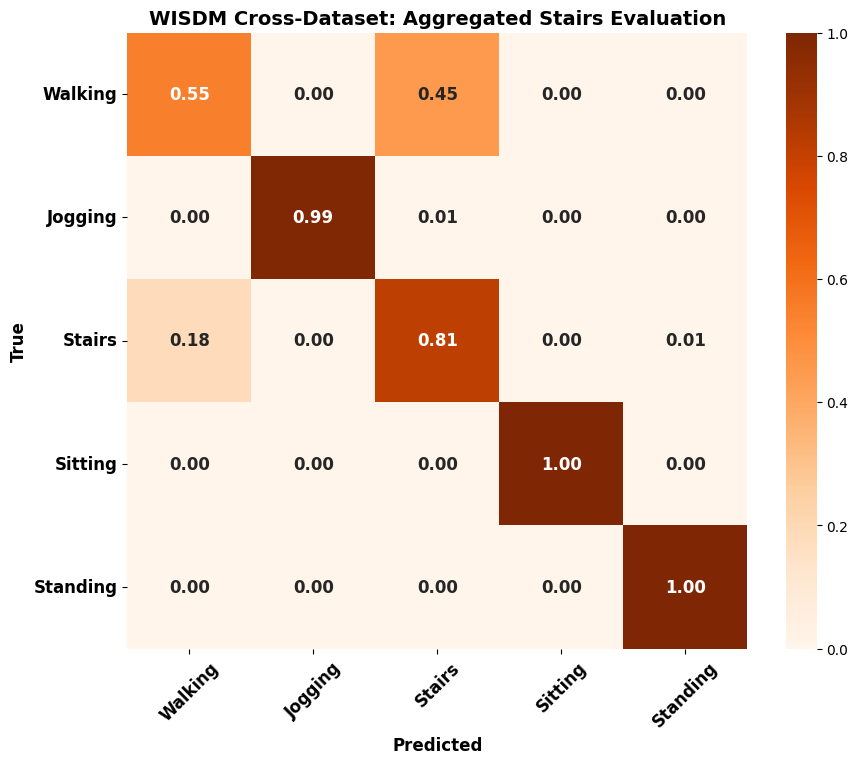

In [7]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K
from sklearn.metrics import classification_report, confusion_matrix

# ================= 1. AttentionLayer (Required for Loading) =================
@tf.keras.utils.register_keras_serializable(package="Custom", name="AttentionLayer")
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='normal', trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        return K.sum(x * a, axis=1)
    def get_config(self):
        return super(AttentionLayer, self).get_config()

# ================= 2. CONFIGURATION =================
WINDOW_SIZE, STEP_SIZE = 128, 64
TARGET_FREQ, ORIGINAL_FREQ = 50, 20

MODEL_PATH = '/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHOUTAUG/final_model_v12_nomirror.keras'
SCALER_PATH = '/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHOUTAUG/scaler_minmax_v12_nomirror.pkl'
BASE_WISDM_DIR = '/content/drive/MyDrive/wisdm/wisdm_data/unzip/wisdm-dataset'

CLASSES_6 = ['Jogging', 'Sitting', 'Standing', 'Walking', 'Walking Downstairs', 'Walking Upstairs']
WISDM_CLASSES_EVAL = ['Walking', 'Jogging', 'Stairs', 'Sitting', 'Standing']
WISDM_MAPPING = {'A': 'Walking', 'B': 'Jogging', 'C': 'Stairs', 'D': 'Sitting', 'E': 'Standing'}

# ================= 3. DATA PREPARATION (WISDM) =================
def prepare_wisdm_data(subject_id='1600'):
    acc_file = f'{BASE_WISDM_DIR}/raw/phone/accel/data_{subject_id}_accel_phone.txt'
    gyro_file = f'{BASE_WISDM_DIR}/raw/phone/gyro/data_{subject_id}_gyro_phone.txt'

    if not os.path.exists(acc_file) or not os.path.exists(gyro_file):
        raise FileNotFoundError(f"User {subject_id} files not found.")

    cols = ['subject','activity','timestamp','x','y','z']
    df_acc = pd.read_csv(acc_file, names=cols, header=None).dropna(subset=['x','y','z'])
    df_gyro = pd.read_csv(gyro_file, names=cols, header=None).dropna(subset=['x','y','z'])

    df_acc['z'] = df_acc['z'].astype(str).str.replace(';','').astype(float)
    df_gyro['z'] = df_gyro['z'].astype(str).str.replace(';','').astype(float)

    df_acc, df_gyro = df_acc.sort_values('timestamp'), df_gyro.sort_values('timestamp')
    df_merged = pd.merge_asof(df_acc, df_gyro, on='timestamp', suffixes=('_acc','_gyro'), direction='nearest')

    df_merged = df_merged[df_merged['activity_acc'].isin(WISDM_MAPPING.keys())].copy()
    df_merged['mapped_activity'] = df_merged['activity_acc'].map(WISDM_MAPPING)

    acc_raw = df_merged[['y_acc','x_acc','z_acc']].values / 9.80665
    gyro_raw = df_merged[['y_gyro','x_gyro','z_gyro']].values
    labels_raw = df_merged['mapped_activity'].values

    num_samples = int(len(acc_raw) * TARGET_FREQ / ORIGINAL_FREQ)
    acc_res = signal.resample(acc_raw, num_samples)
    gyro_res = signal.resample(gyro_raw, num_samples)
    labels_res = labels_raw[np.linspace(0, len(labels_raw)-1, num_samples).astype(int)]

    b, a = signal.butter(4, 0.3/(TARGET_FREQ/2), btype='low')
    gravity = signal.filtfilt(b, a, acc_res, axis=0)
    user_acc = acc_res - gravity

    features_9c = np.concatenate([user_acc, gyro_res, acc_res], axis=1)

    X_list, y_list = [], []
    for start in range(0, len(features_9c)-WINDOW_SIZE+1, STEP_SIZE):
        X_list.append(features_9c[start:start+WINDOW_SIZE])
        unique, counts = np.unique(labels_res[start:start+WINDOW_SIZE], return_counts=True)
        majority_label = unique[np.argmax(counts)]
        y_list.append(WISDM_CLASSES_EVAL.index(majority_label))

    return np.array(X_list), np.array(y_list)

# ================= 4. EXECUTION & AGGREGATION =================
try:
    print("⏳ Loading model and scaler...")
    model = load_model(MODEL_PATH, custom_objects={'AttentionLayer': AttentionLayer}, compile=False)
    with open(SCALER_PATH, 'rb') as f: scaler = pickle.load(f)

    print("📥 Preparing WISDM data (User 1600)...")
    X_test, y_test = prepare_wisdm_data('1600')

    if len(X_test) > 0:
        samples, steps, channels = X_test.shape
        X_test_scaled = scaler.transform(X_test.reshape(-1, channels)).reshape(samples, steps, channels)

        raw_probs = model.predict(X_test_scaled)

        agg_probs = np.zeros((samples, 5))
        agg_probs[:, 0] = raw_probs[:, 3]
        agg_probs[:, 1] = raw_probs[:, 0]
        agg_probs[:, 2] = raw_probs[:, 4] + raw_probs[:, 5]
        agg_probs[:, 3] = raw_probs[:, 1]
        agg_probs[:, 4] = raw_probs[:, 2]

        y_pred = np.argmax(agg_probs, axis=1)

        print("\n✅ Classification Report (Aggregated for WISDM):")
        print(classification_report(y_test, y_pred, target_names=WISDM_CLASSES_EVAL))

        # ================= Confusion Matrix with bigger bold labels =================
        cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
        plt.figure(figsize=(10,8))
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
                    xticklabels=WISDM_CLASSES_EVAL, yticklabels=WISDM_CLASSES_EVAL,
                    annot_kws={"fontsize": 12, "fontweight": "bold"},
                    cbar=True)
        plt.title('WISDM Cross-Dataset: Aggregated Stairs Evaluation', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted', fontsize=12, fontweight='bold')
        plt.ylabel('True', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, fontsize=12, fontweight='bold')
        plt.yticks(rotation=0, fontsize=12, fontweight='bold')
        plt.show()
    else:
        print("❌ No valid segments found.")
except Exception as e:
    print(f"❌ Error: {e}")

# Statistical Analysis

📊 Starting deep signal analysis across 60 samples (20 per class)...


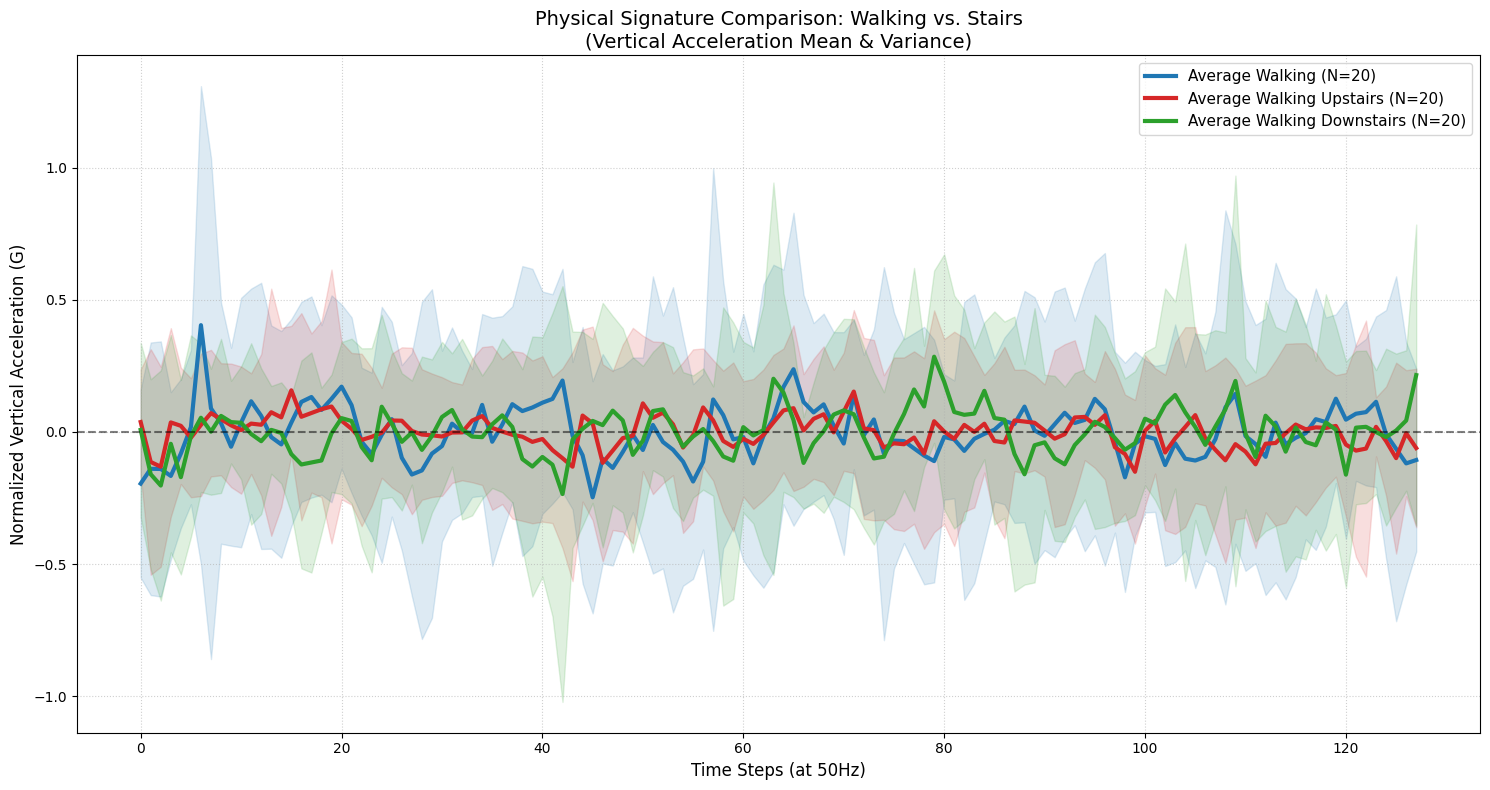


✅ Analysis complete. Please examine the peak intensity and frequency of the waves.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ================= 1. CONFIGURATION & PATHS =================
# Path to the raw MotionSense folders
MS_BASE_DIR = '/content/drive/MyDrive/motion-sense-dataset/motion_sense_extracted/A_DeviceMotion_data'

# We compare these three specific activities
TARGET_CLASSES = {
    'wlk': 'Walking',
    'ups': 'Walking Upstairs',
    'dws': 'Walking Downstairs'
}

SAMPLES_PER_CLASS = 20
WINDOW_SIZE = 128  # Analyzing a 2.56-second window (at 50Hz)

# ================= 2. DATA EXTRACTION ENGINE =================
def extract_class_patterns(prefix, num_required):
    all_windows = []
    found_count = 0

    # Sort folders to ensure reproducible results
    folders = sorted([f for f in os.listdir(MS_BASE_DIR) if f.startswith(prefix)])

    for folder_name in folders:
        if found_count >= num_required:
            break

        folder_path = os.path.join(MS_BASE_DIR, folder_name)
        if not os.path.isdir(folder_path):
            continue

        # Scan all CSV files in the folder
        for file_name in sorted(os.listdir(folder_path)):
            if file_name.endswith('.csv') and found_count < num_required:
                file_path = os.path.join(folder_path, file_name)

                try:
                    df = pd.read_csv(file_path).dropna()

                    # Vertical Energy Signal (Gravity Z + User Acceleration Z)
                    # This is the most critical axis for distinguishing elevation changes
                    z_signal = df['userAcceleration.z'].values + df['gravity.z'].values

                    # Extract a stable segment from the middle of the recording
                    if len(z_signal) > WINDOW_SIZE + 200:
                        mid_point = len(z_signal) // 2
                        segment = z_signal[mid_point : mid_point + WINDOW_SIZE]

                        # Zero-mean normalization for shape comparison
                        segment = segment - np.mean(segment)

                        all_windows.append(segment)
                        found_count += 1
                except Exception as e:
                    print(f"Error reading {file_name}: {e}")

    return np.array(all_windows)

# ================= 3. STATISTICAL ANALYSIS & PLOTTING =================
print("📊 Starting deep signal analysis across 60 samples (20 per class)...")

plt.figure(figsize=(15, 8))
colors = {'wlk': '#1f77b4', 'ups': '#d62728', 'dws': '#2ca02c'}

for prefix, label in TARGET_CLASSES.items():
    data = extract_class_patterns(prefix, SAMPLES_PER_CLASS)

    if len(data) > 0:
        # Calculate the Mean Pattern
        mean_pattern = np.mean(data, axis=0)
        # Calculate Standard Deviation for the "Shadow" (uncertainty)
        std_pattern = np.std(data, axis=0)

        # Plotting the Mean line
        plt.plot(mean_pattern, label=f'Average {label} (N={len(data)})',
                 color=colors[prefix], linewidth=3)

        # Plotting the variance shadow
        plt.fill_between(range(WINDOW_SIZE),
                         mean_pattern - std_pattern,
                         mean_pattern + std_pattern,
                         color=colors[prefix], alpha=0.15)

plt.title('Physical Signature Comparison: Walking vs. Stairs\n(Vertical Acceleration Mean & Variance)', fontsize=14)
plt.xlabel('Time Steps (at 50Hz)', fontsize=12)
plt.ylabel('Normalized Vertical Acceleration (G)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n✅ Analysis complete. Please examine the peak intensity and frequency of the waves.")

📊 Analyzing 60 samples for physical signatures...

--- EXTRACTED PHYSICAL DATA (Averages from 20 Samples) ---
          Activity  Max_Impact_G  Min_Impact_G  RMS_Energy  Zero_Crossings
           Walking      0.404063     -0.247571    0.097820              34
  Walking Upstairs      0.157409     -0.150895    0.057588              35
Walking Downstairs      0.284719     -0.235134    0.086177              42


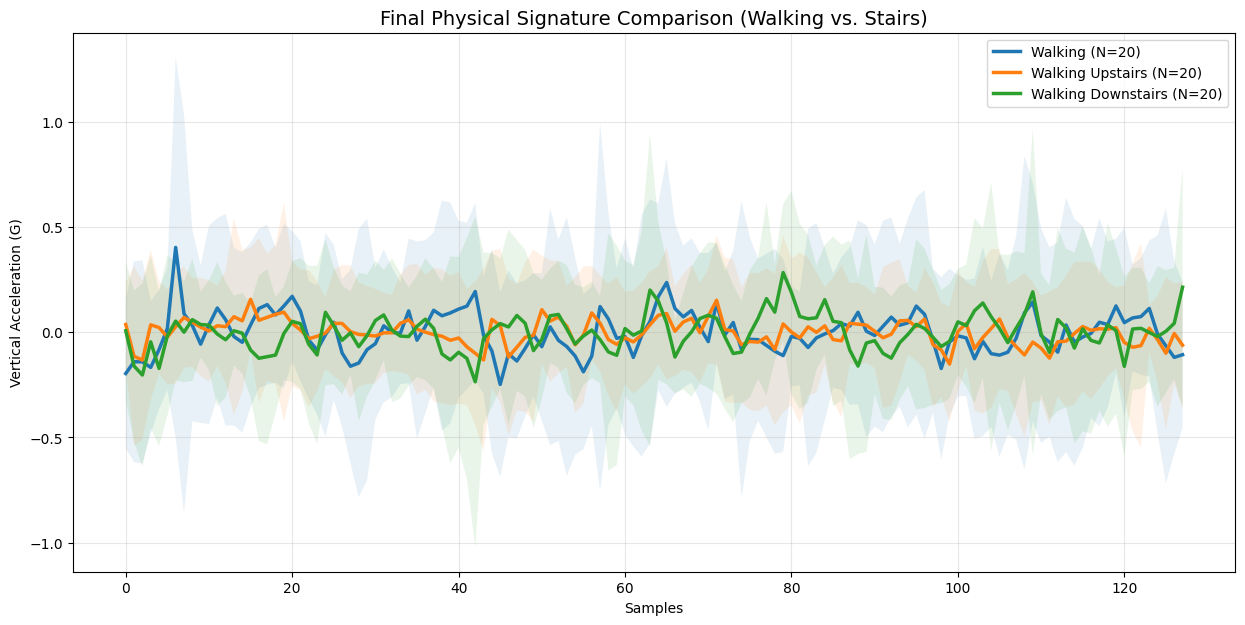

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ================= 1. CONFIGURATION =================
MS_BASE_DIR = '/content/drive/MyDrive/motion-sense-dataset/motion_sense_extracted/A_DeviceMotion_data'
TARGET_CLASSES = {'wlk': 'Walking', 'ups': 'Walking Upstairs', 'dws': 'Walking Downstairs'}

# MODIFIED: Changed from 25 to 20 to match the requested subset
SAMPLES_PER_CLASS = 20
WINDOW_SIZE = 128

# ================= 2. EXTRACTION & ANALYSIS ENGINE =================
def analyze_activity_signatures():
    results = []
    plot_data = {}

    for prefix, label in TARGET_CLASSES.items():
        all_signals = []
        found_count = 0
        folders = sorted([f for f in os.listdir(MS_BASE_DIR) if f.startswith(prefix)])

        for folder in folders:
            if found_count >= SAMPLES_PER_CLASS: break
            f_path = os.path.join(MS_BASE_DIR, folder)
            for file in sorted(os.listdir(f_path)):
                if file.endswith('.csv') and found_count < SAMPLES_PER_CLASS:
                    df = pd.read_csv(os.path.join(f_path, file))
                    # Combined Z-axis signal (Physical Vertical Motion)
                    z_sig = df['userAcceleration.z'].values + df['gravity.z'].values

                    if len(z_sig) > WINDOW_SIZE + 200:
                        seg = z_sig[len(z_sig)//2 : len(z_sig)//2 + WINDOW_SIZE]
                        seg = seg - np.mean(seg) # DC offset removal
                        all_signals.append(seg)
                        found_count += 1

        if all_signals:
            all_signals = np.array(all_signals)
            mean_sig = np.mean(all_signals, axis=0)

            # Extracting Numerical Data for "Informed Augmentation"
            stats = {
                'Activity': label,
                'Max_Impact_G': np.max(mean_sig),
                'Min_Impact_G': np.min(mean_sig),
                'RMS_Energy': np.sqrt(np.mean(mean_sig**2)),
                'Zero_Crossings': ((mean_sig[:-1] * mean_sig[1:]) < 0).sum()
            }
            results.append(stats)
            # MODIFIED: Storing for plotting with correct N=20 label
            plot_data[label] = (mean_sig, np.std(all_signals, axis=0))

    return pd.DataFrame(results), plot_data

# ================= 3. EXECUTION & VISUALIZATION =================
print(f"📊 Analyzing {len(TARGET_CLASSES)*SAMPLES_PER_CLASS} samples for physical signatures...")
stats_df, plots = analyze_activity_signatures()

# Display Numerical Results
# MODIFIED: Header updated to reflect N=20
print("\n--- EXTRACTED PHYSICAL DATA (Averages from 20 Samples) ---")
print(stats_df.to_string(index=False))

# Visualization
plt.figure(figsize=(15, 7))
for label, (mean_sig, std_sig) in plots.items():
    # MODIFIED: Legend updated to N=20
    plt.plot(mean_sig, label=f'{label} (N=20)', linewidth=2.5)
    plt.fill_between(range(WINDOW_SIZE), mean_sig-std_sig, mean_sig+std_sig, alpha=0.1)

plt.title('Final Physical Signature Comparison (Walking vs. Stairs)', fontsize=14)
plt.ylabel('Vertical Acceleration (G)'); plt.xlabel('Samples'); plt.grid(True, alpha=0.3)
plt.legend(); plt.show()



# ADJUST NOISE ACCORDING ABOVE PICTURE



In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Layer, Dense
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from scipy.interpolate import interp1d
from google.colab import files

# ================= 1. CONFIGURATION & PATHS =================
OLD_MODEL_PATH = '/content/drive/MyDrive/RF_COMBINATION/UCILSTM-CNN/Model_A_Attention_FP32/best_keras_model.h5'
MS_BASE_DIR = '/content/drive/MyDrive/motion-sense-dataset/motion_sense_extracted/A_DeviceMotion_data'
BASE_SAVE_DIR = '/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2'
os.makedirs(BASE_SAVE_DIR, exist_ok=True)

NEW_SCALER_PATH = os.path.join(BASE_SAVE_DIR, 'scaler_final.pkl')
NEW_MODEL_PATH = os.path.join(BASE_SAVE_DIR, 'final_pocket_model.keras')

WINDOW_SIZE = 128
STEP_SIZE = 64
MAX_ROWS_PER_SEGMENT = 200

CLASSES = ['Jogging', 'Sitting', 'Standing', 'Walking', 'Walking Downstairs', 'Walking Upstairs']
FOLDER_MAP = {
    'jog': 'Jogging', 'sit': 'Sitting', 'std': 'Standing',
    'wlk': 'Walking', 'dws': 'Walking Downstairs', 'ups': 'Walking Upstairs'
}

# ================= 2. CUSTOM ATTENTION LAYER =================
@tf.keras.utils.register_keras_serializable(package="Custom", name="AttentionLayer")
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1],1), initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(input_shape[1],1), initializer='zeros', trainable=True)
        super().build(input_shape)
    def call(self, x):
        e = K.tanh(K.dot(x,self.W)+self.b)
        a = K.softmax(e, axis=1)
        return K.sum(x*a, axis=1)
    def get_config(self):
        return super(AttentionLayer, self).get_config()

# ================= 3. DATA SEGMENTATION & TRUE AXIS ALIGNMENT =================
print("📥 Scanning folders and aligning axes (Pocket-Physics Aware)...")
data_list = []

for folder in sorted(os.listdir(MS_BASE_DIR)):
    prefix = folder.split('_')[0]
    if prefix in FOLDER_MAP:
        label = FOLDER_MAP[prefix]
        folder_path = os.path.join(MS_BASE_DIR, folder)
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                if file.endswith('.csv'):
                    f_df = pd.read_csv(os.path.join(folder_path, file)).dropna()
                    f_df['Label'] = label
                    f_df['Row_Idx'] = np.arange(len(f_df))
                    f_df['Sub_Seg_Idx'] = f_df['Row_Idx'] // MAX_ROWS_PER_SEGMENT
                    f_df['SegmentID'] = f"{folder}_{file}_" + f_df['Sub_Seg_Idx'].astype(str)
                    data_list.append(f_df)

df_all = pd.concat(data_list, ignore_index=True)
segment_meta = df_all.groupby('SegmentID')['Label'].first().reset_index()
train_segs, val_segs = train_test_split(segment_meta, test_size=0.2, random_state=42, stratify=segment_meta['Label'])

train_df = df_all[df_all['SegmentID'].isin(train_segs['SegmentID'])]
val_df   = df_all[df_all['SegmentID'].isin(val_segs['SegmentID'])]

def create_windows(df_input):
    X_list, y_list = [], []
    for _, seg_df in df_input.groupby('SegmentID'):
        label_idx = CLASSES.index(seg_df['Label'].iloc[0])
        # AXIS ALIGNMENT (Y, X, Z) - Swapping only, No negative mirroring
        ba_x, ba_y, ba_z = seg_df['userAcceleration.y'].values, seg_df['userAcceleration.x'].values, seg_df['userAcceleration.z'].values
        gy_x, gy_y, gy_z = seg_df['rotationRate.y'].values, seg_df['rotationRate.x'].values, seg_df['rotationRate.z'].values
        g_x, g_y, g_z = seg_df['gravity.y'].values, seg_df['gravity.x'].values, seg_df['gravity.z'].values
        t_x, t_y, t_z = ba_x + g_x, ba_y + g_y, ba_z + g_z

        features = np.stack([ba_x, ba_y, ba_z, gy_x, gy_y, gy_z, t_x, t_y, t_z], axis=1)
        if len(features) >= WINDOW_SIZE:
            for start in range(0, len(features)-WINDOW_SIZE+1, STEP_SIZE):
                X_list.append(features[start:start+WINDOW_SIZE])
                y_list.append(label_idx)
    return np.array(X_list), np.array(y_list)

X_train_raw, y_train = create_windows(train_df)
X_val_raw, y_val     = create_windows(val_df)

# ================= 4. INFORMED POCKET AUGMENTATION (N=25 Insight) =================
# ================= 4. INFORMED POCKET AUGMENTATION =================
def augment_stairs_pocket_aware(sample, activity_label):
    sample = sample.copy()

    # 1. Pocket Looseness: Jittering orientation (Gyro & Gravity)
    orientation_noise = np.random.normal(0, 0.002, (sample.shape[0], 6))
    sample[:, 3:9] += orientation_noise

    if activity_label == 'Walking Downstairs':
        # Targeting High Frequency and Sharp Impacts
        sample += np.random.normal(0, 0.0015, sample.shape)

        # FIXED: Applying mask per column to avoid IndexError
        for col_idx in [2, 8]:
            mask = sample[:, col_idx] < 0 # Target downward thuds
            sample[mask, col_idx] *= 1.08

    elif activity_label == 'Walking Upstairs':
        # Targeting Low Energy and Mid Frequency
        sample += np.random.normal(0, 0.0008, sample.shape)
        if np.random.rand() < 0.6:
            sample = np.roll(sample, np.random.randint(-2, 2), axis=0)
    return sample

def augment_data(X, y):
    unique, counts = np.unique(y, return_counts=True)
    max_count = np.max(counts)

    X_aug, y_aug = list(X), list(y)
    aug_stats = {CLASSES[i]: {'Original': counts[i], 'Added': 0} for i in range(len(unique))}

    print("\n--- Generating Synthetic Data for Class Balancing ---")
    for cls_idx, count in zip(unique, counts):
        if count < max_count:
            n_to_add = max_count - count
            cls_indices = np.where(y == cls_idx)[0]

            aug_stats[CLASSES[cls_idx]]['Added'] = n_to_add

            for _ in range(n_to_add):
                rand_idx = np.random.choice(cls_indices)
                sample = X[rand_idx]

                if CLASSES[cls_idx] in ['Walking Upstairs', 'Walking Downstairs']:
                    new_sample = augment_stairs_pocket_aware(sample, CLASSES[cls_idx])
                else:
                    new_sample = sample + np.random.normal(0, 0.001, sample.shape)

                X_aug.append(new_sample)
                y_aug.append(cls_idx)

    # Displaying the summary table
    print(f"{'Activity':<20} | {'Original':<10} | {'Added (Noise)':<15} | {'Total':<10}")
    print("-" * 65)
    for activity, stat in aug_stats.items():
        total = stat['Original'] + stat['Added']
        print(f"{activity:<20} | {stat['Original']:<10} | {stat['Added']:<15} | {total:<10}")

    return np.array(X_aug), np.array(y_aug)

print("🛠 Initializing Informed Augmentation Engine...")
X_train_aug, y_train_aug = augment_data(X_train_raw, y_train)

# ================= 5. SCALING & TRAINING =================
# Rest of the code remains the same...

# ================= 5. SCALING & TRAINING =================
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(X_train_aug.reshape(-1, 9))
X_train = scaler.transform(X_train_aug.reshape(-1, 9)).reshape(X_train_aug.shape)
X_val   = scaler.transform(X_val_raw.reshape(-1, 9)).reshape(X_val_raw.shape)

with open(NEW_SCALER_PATH,'wb') as f: pickle.dump(scaler, f)

y_train_cat = to_categorical(y_train_aug, 6)
y_val_cat   = to_categorical(y_val, 6)

custom_objects = {'AttentionLayer': AttentionLayer}
model = load_model(OLD_MODEL_PATH, custom_objects=custom_objects, compile=False)
x = model.layers[-2].output
new_out = Dense(len(CLASSES), activation='softmax', name='output')(x)
model = Model(inputs=model.input, outputs=new_out)
for layer in model.layers: layer.trainable = True

model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
callbacks = [
    LearningRateScheduler(lambda e, lr: 1e-4*(e+1)/3 if e<3 else lr),
    ModelCheckpoint(NEW_MODEL_PATH, save_best_only=True, monitor='val_accuracy', mode='max'),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
]

print("🚀 Final Training Launch...")
history = model.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat), epochs=25, batch_size=64, callbacks=callbacks)

# ================= 6. EVALUATION =================
y_pred = np.argmax(model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(9,7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title("Final Pocket-Aware Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(BASE_SAVE_DIR, 'confusion_matrix.png'), dpi=300)
plt.show()

print("\n✅ Final Classification Report:")
print(classification_report(y_val, y_pred, target_names=CLASSES))

# Wisdm validation

⏳ Loading model and scaler...
📥 Preparing WISDM data (User 1600)...
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step

✅ Classification Report (Aggregated for WISDM):
              precision    recall  f1-score   support

     Walking       0.84      0.93      0.88       138
     Jogging       1.00      0.84      0.91       140
      Stairs       0.83      0.85      0.84       139
     Sitting       1.00      1.00      1.00       139
    Standing       0.97      1.00      0.99       140

    accuracy                           0.92       696
   macro avg       0.93      0.92      0.92       696
weighted avg       0.93      0.92      0.92       696



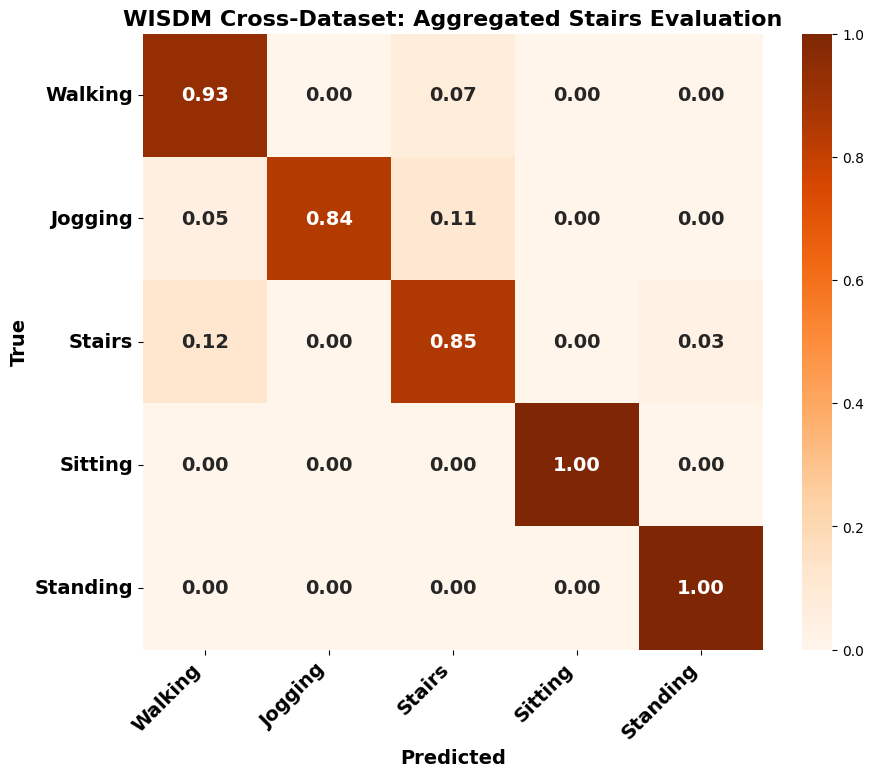

In [13]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K
from sklearn.metrics import classification_report, confusion_matrix

# ================= 1. AttentionLayer (Required for Loading) =================
@tf.keras.utils.register_keras_serializable(package="Custom", name="AttentionLayer")
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='normal', trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        return K.sum(x * a, axis=1)
    def get_config(self):
        return super(AttentionLayer, self).get_config()

# ================= 2. CONFIGURATION =================
WINDOW_SIZE, STEP_SIZE = 128, 64
TARGET_FREQ, ORIGINAL_FREQ = 50, 20

MODEL_PATH = '/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2/final_pocket_model.keras'
SCALER_PATH = '/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2/scaler_final.pkl'
BASE_WISDM_DIR = '/content/drive/MyDrive/wisdm/wisdm_data/unzip/wisdm-dataset'

CLASSES_6 = ['Jogging', 'Sitting', 'Standing', 'Walking', 'Walking Downstairs', 'Walking Upstairs']
WISDM_CLASSES_EVAL = ['Walking', 'Jogging', 'Stairs', 'Sitting', 'Standing']
WISDM_MAPPING = {'A': 'Walking', 'B': 'Jogging', 'C': 'Stairs', 'D': 'Sitting', 'E': 'Standing'}

# ================= 3. DATA PREPARATION (WISDM) =================
def prepare_wisdm_data(subject_id='1600'):
    acc_file = f'{BASE_WISDM_DIR}/raw/phone/accel/data_{subject_id}_accel_phone.txt'
    gyro_file = f'{BASE_WISDM_DIR}/raw/phone/gyro/data_{subject_id}_gyro_phone.txt'

    if not os.path.exists(acc_file) or not os.path.exists(gyro_file):
        raise FileNotFoundError(f"User {subject_id} files not found.")

    cols = ['subject','activity','timestamp','x','y','z']
    df_acc = pd.read_csv(acc_file, names=cols, header=None).dropna(subset=['x','y','z'])
    df_gyro = pd.read_csv(gyro_file, names=cols, header=None).dropna(subset=['x','y','z'])

    df_acc['z'] = df_acc['z'].astype(str).str.replace(';','').astype(float)
    df_gyro['z'] = df_gyro['z'].astype(str).str.replace(';','').astype(float)

    df_acc, df_gyro = df_acc.sort_values('timestamp'), df_gyro.sort_values('timestamp')
    df_merged = pd.merge_asof(df_acc, df_gyro, on='timestamp', suffixes=('_acc','_gyro'), direction='nearest')
    df_merged = df_merged[df_merged['activity_acc'].isin(WISDM_MAPPING.keys())].copy()
    df_merged['mapped_activity'] = df_merged['activity_acc'].map(WISDM_MAPPING)

    # Pocket Alignment (Y, X, Z)
    acc_raw = df_merged[['y_acc','x_acc','z_acc']].values / 9.80665
    gyro_raw = df_merged[['y_gyro','x_gyro','z_gyro']].values
    labels_raw = df_merged['mapped_activity'].values

    # Resampling to 50Hz
    num_samples = int(len(acc_raw) * TARGET_FREQ / ORIGINAL_FREQ)
    acc_res = signal.resample(acc_raw, num_samples)
    gyro_res = signal.resample(gyro_raw, num_samples)
    labels_res = labels_raw[np.linspace(0, len(labels_raw)-1, num_samples).astype(int)]

    # Gravity Removal
    b, a = signal.butter(4, 0.3/(TARGET_FREQ/2), btype='low')
    gravity = signal.filtfilt(b, a, acc_res, axis=0)
    user_acc = acc_res - gravity

    features_9c = np.concatenate([user_acc, gyro_res, acc_res], axis=1)

    X_list, y_list = [], []
    for start in range(0, len(features_9c)-WINDOW_SIZE+1, STEP_SIZE):
        X_list.append(features_9c[start:start+WINDOW_SIZE])
        unique, counts = np.unique(labels_res[start:start+WINDOW_SIZE], return_counts=True)
        majority_label = unique[np.argmax(counts)]
        y_list.append(WISDM_CLASSES_EVAL.index(majority_label))

    return np.array(X_list), np.array(y_list)

# ================= 4. EXECUTION & AGGREGATION =================
try:
    print("⏳ Loading model and scaler...")
    model = load_model(MODEL_PATH, custom_objects={'AttentionLayer': AttentionLayer}, compile=False)
    with open(SCALER_PATH, 'rb') as f: scaler = pickle.load(f)

    print("📥 Preparing WISDM data (User 1600)...")
    X_test, y_test = prepare_wisdm_data('1600')

    if len(X_test) > 0:
        samples, steps, channels = X_test.shape
        X_test_scaled = scaler.transform(X_test.reshape(-1, channels)).reshape(samples, steps, channels)
        raw_probs = model.predict(X_test_scaled)

        # Aggregation: 6-class → 5-class WISDM
        agg_probs = np.zeros((samples, 5))
        agg_probs[:, 0] = raw_probs[:, 3]  # Walking
        agg_probs[:, 1] = raw_probs[:, 0]  # Jogging
        agg_probs[:, 2] = raw_probs[:, 4] + raw_probs[:, 5]  # Stairs
        agg_probs[:, 3] = raw_probs[:, 1]  # Sitting
        agg_probs[:, 4] = raw_probs[:, 2]  # Standing

        y_pred = np.argmax(agg_probs, axis=1)

        # Results
        print("\n✅ Classification Report (Aggregated for WISDM):")
        print(classification_report(y_test, y_pred, target_names=WISDM_CLASSES_EVAL))

        # ================= 5. CONFUSION MATRIX =================
        cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
        plt.figure(figsize=(10,8))

        # Heatmap with large, bold numbers
        heatmap = sns.heatmap(
            cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=WISDM_CLASSES_EVAL, yticklabels=WISDM_CLASSES_EVAL,
            annot_kws={"size":14, "weight":"bold"}  # Large & bold text inside cells
        )

        # Large, bold class labels on axes
        heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=14, fontweight='bold')
        heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, fontsize=14, fontweight='bold')

        plt.title('WISDM Cross-Dataset: Aggregated Stairs Evaluation', fontsize=16, fontweight='bold')
        plt.xlabel('Predicted', fontsize=14, fontweight='bold')
        plt.ylabel('True', fontsize=14, fontweight='bold')
        plt.show()
    else:
        print("❌ No valid segments found.")
except Exception as e:
    print(f"❌ Error: {e}")

# FIX

#Convert to coreml

16 bit

In [ ]:
!pip install "numpy<2.0" tf2onnx coremltools --force-reinstall

# connect to drive

In [ ]:
# Import the drive module from google.colab
from google.colab import drive

# Mount Google Drive to the specified directory
# This will require interactive authorization
drive.mount('/content/drive')

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import coremltools as ct
import tensorflow as tf
import tf_keras as keras
from tf_keras.layers import Layer, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input, BatchNormalization
from tf_keras.models import Model, load_model
from google.colab import drive

# List of classes: Jogging replaces Laying (6 classes)
ACTIVITY_LABELS = ["Jogging", "Sitting", "Standing", "Walking", "Walking Downstairs", "Walking Upstairs"]

MODEL_PATH = '/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2/final_pocket_model.keras'
SCALER_PATH ='/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2/scaler_final.pkl'
SAVE_DIR = "/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2/CoreML_Exports/16bit"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# ==========================================
# 2. Define Attention Layer (Calibrated for CoreML)
# ==========================================
@keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='normal',
                                 trainable=True)
        self.b = self.add_weight(name='att_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # Use matmul for better stability on older engines
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)

# ==========================================
# 3. Rebuild the model and load weights
# ==========================================
def build_clean_model():
    input_layer = Input(shape=(128, 9), name="input_1")

    x = Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(128, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = LSTM(100, return_sequences=True)(x)
    x = Dropout(0.5)(x)

    x = AttentionLayer(name="attention_layer")(x)

    # 6-class output
    output_layer = Dense(6, activation='softmax', name="output_probs")(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    return model

print("--- 🏗️ Building Model for 16-Bit Export ---")
clean_model = build_clean_model()

try:
    source_model = load_model(MODEL_PATH, custom_objects={'AttentionLayer': AttentionLayer})
    clean_model.set_weights(source_model.get_weights())
    print("✅ Weights transferred successfully.")
except Exception as e:
    print(f"⚠️ Initial weight transfer failed, using fallback: {e}")
    clean_model.load_weights(MODEL_PATH)

# Temporary save
TEMP_TF_PATH = "/content/temp_model_16bit"
clean_model.save(TEMP_TF_PATH, save_format="tf")

# ==========================================
# 4. Convert to CoreML and 16-bit quantization
# ==========================================
def export_16bit_mlpackage():
    print(f"\n--- 🔄 Exporting 16-Bit .mlpackage ---")

    file_name = "HAR_Hybrid_NN_Float16.mlpackage"
    final_path = os.path.join(SAVE_DIR, file_name)

    try:
        # Step 1: Initial conversion to NeuralNetwork (FP32)
        print("Step 1: Converting to NeuralNetwork...")
        mlmodel = ct.convert(
            TEMP_TF_PATH,
            source="tensorflow",
            inputs=[ct.TensorType(shape=(1, 128, 9), name="input_1")],
            classifier_config=ct.ClassifierConfig(ACTIVITY_LABELS),
            convert_to="neuralnetwork"
        )

        # Step 2: Quantize weights to Float16 to reduce size and optimize
        print("Step 2: Quantizing weights to 16-bit (Float16)...")
        model_16bit = ct.models.neural_network.quantization_utils.quantize_weights(mlmodel, nbits=16)

        # Set metadata
        model_16bit.short_description = "Hybrid HAR: CNN-LSTM-Attention (16-Bit NeuralNetwork)"
        model_16bit.author = "Research Team"

        # Step 3: Save as .mlpackage
        model_16bit.save(final_path)
        print(f"✅ Success! 16-bit model saved to: {final_path}")

    except Exception as e:
        print(f"❌ 16-bit Conversion failed: {e}")

# Run export
export_16bit_mlpackage()

print("\n🏁 PROCESS COMPLETE.")

#test json

In [ ]:
# 1. Force Keras 3 BEFORE any libraries are loaded
import os
os.environ['TF_USE_LEGACY_KERAS'] = '0'

import json
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
import keras
from keras.models import load_model
from keras.layers import Layer

# ================= 1. CONFIGURATION =================
MOTIONSENSE_CSV = '/content/drive/MyDrive/Master_MotionSense_UCI_Format.csv'


MODEL_PATH = '/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2/final_pocket_model.keras'
SCALER_PATH ='/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2/scaler_final.pkl'
SAVE_DIR = "/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2/CoreML_Exports/json"


JSON_FILENAME = "Motion_test_data_tune.json"

WINDOW_SIZE = 128
CLASSES = ["Jogging", "Sitting", "Standing", "Walking", "Walking Downstairs", "Walking Upstairs"]

# ================= 2. CUSTOM ATTENTION LAYER (KERAS 3 COMPLIANT) =================
@keras.saving.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        # Keras 3: Using native TensorFlow math operations instead of deprecated Keras Backend
        e = tf.math.tanh(tf.linalg.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        return tf.reduce_sum(x * a, axis=1)

# ================= 3. LOAD RESOURCES =================
print("--- 📥 Loading Dataset, Model, and Scaler ---")
df_full = pd.read_csv(MOTIONSENSE_CSV)

with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)

# Load Model with custom objects mapping both possible namings
custom_objects = {
    'AttentionLayer': AttentionLayer,
    'Custom>AttentionLayer': AttentionLayer
}
model = load_model(MODEL_PATH, custom_objects=custom_objects)
print("✅ Model successfully loaded in Keras 3 Native Mode!")

# ================= 4. GENERATE 20 RANDOM SAMPLES =================
print("--- 🧪 Generating 20 Validation Samples for Xcode ---")

parity_data = []
sample_count = 0

while sample_count < 20:
    start_idx = np.random.randint(0, len(df_full) - WINDOW_SIZE)
    window_df = df_full.iloc[start_idx : start_idx + WINDOW_SIZE]

    if window_df['Label'].nunique() == 1:
        try:
            u_acc = window_df[['UserAccY', 'UserAccX', 'UserAccZ']].values
            gyro  = window_df[['GyroY', 'GyroX', 'GyroZ']].values
            t_acc = window_df[['TotalAccY', 'TotalAccX', 'TotalAccZ']].values

            features = np.concatenate([u_acc, gyro, t_acc], axis=1)

            features_scaled = scaler.transform(features)

            input_tensor = features_scaled.reshape(1, WINDOW_SIZE, 9)
            pred_probs = model.predict(input_tensor, verbose=0)[0]
            top_idx = np.argmax(pred_probs)

            real_label = window_df['Label'].iloc[0]

            sample = {
                "sample_id": sample_count + 1,
                "real_activity": str(real_label),
                "top_prediction": CLASSES[top_idx],
                "confidence": round(float(pred_probs[top_idx]) * 100, 2),
                "sensor_data": features_scaled.tolist(),
                "expected_probs": {CLASSES[k]: round(float(pred_probs[k]), 6) for k in range(len(CLASSES))}
            }

            parity_data.append(sample)
            sample_count += 1
            print(f"✅ Sample {sample_count:02d}/20 added | True: {real_label:<18} | Pred: {CLASSES[top_idx]} ({sample['confidence']}%)")

        except KeyError as e:
            print(f"❌ Column names mismatch: {e}. Please check the CSV header.")
            break

# ================= 5. SAVE JSON EXPORT =================
if parity_data:
    os.makedirs(SAVE_DIR, exist_ok=True)
    full_path = os.path.join(SAVE_DIR, JSON_FILENAME)

    with open(full_path, 'w', encoding='utf-8') as f:
        json.dump(parity_data, f, indent=4)

    print(f"\n🏁 SUCCESS! JSON generated for CoreML Parity Testing:\n📂 {full_path}")

# Get numerical values

In [ ]:
import pickle

with open('/content/drive/MyDrive/RF_COMBINATION/OLDM/WITHAUG/2/scaler_final.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("--- New numbers for Swift file ---")
print(f"scalerMin = {scaler.min_.tolist()}")
print(f"scalerScale = {scaler.scale_.tolist()}")